# Aditya Rana
# I059
# B.Tech AI B2 Batch
# Lab 7

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu
import nltk
import re, os, warnings
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}, Device: {device}")

PyTorch: 2.11.0+cu128, Device: cuda


In [2]:
# --- Shared Utilities: Vocab, Dataset, Training, Evaluation ---

class Vocab:
    def __init__(self):
        self.word2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.idx2word = {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>'}
        self.n = 4

    def build(self, sentences, min_freq=1):
        counter = Counter()
        for s in sentences:
            counter.update(s.split())
        for w, c in counter.items():
            if c >= min_freq and w not in self.word2idx:
                self.word2idx[w] = self.n
                self.idx2word[self.n] = w
                self.n += 1

    def encode(self, sentence, max_len):
        tokens = [self.word2idx.get(w, 3) for w in sentence.split()][:max_len]
        return tokens + [0] * (max_len - len(tokens))

    def decode(self, indices):
        words = []
        for idx in indices:
            if idx == 2: break
            if idx > 2: words.append(self.idx2word.get(idx, ''))
        return ' '.join(words)

class TranslationDataset(Dataset):
    def __init__(self, src_data, tgt_data, src_vocab, tgt_vocab, max_src, max_tgt):
        self.src = [torch.tensor(src_vocab.encode(s, max_src)) for s in src_data]
        self.tgt_in = [torch.tensor(tgt_vocab.encode('<sos> ' + s, max_tgt)) for s in tgt_data]
        self.tgt_out = [torch.tensor(tgt_vocab.encode(s + ' <eos>', max_tgt)) for s in tgt_data]

    def __len__(self): return len(self.src)
    def __getitem__(self, i): return self.src[i], self.tgt_in[i], self.tgt_out[i]

def train_model(model, loader, epochs, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    model.train()
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            out = model(src, tgt_in)
            loss = criterion(out.view(-1, out.size(-1)), tgt_out.view(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg = total_loss / len(loader)
        losses.append(avg)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg:.4f}")
    return losses

def evaluate_bleu(model, test_df, src_vocab, tgt_vocab, max_src, max_tgt, translate_fn, n=100):
    bleu_scores = []
    for _, row in test_df.head(n).iterrows():
        pred = translate_fn(model, row.iloc[0], src_vocab, tgt_vocab, max_src, max_tgt)
        ref = row.iloc[1].split()
        hyp = pred.split()
        if ref and hyp:
            score = sentence_bleu([ref], hyp, weights=(0.5, 0.5, 0, 0))
            bleu_scores.append(score)
    return np.mean(bleu_scores) if bleu_scores else 0.0

print("Utilities defined.")

Utilities defined.


## Task 1: English to Hindi Machine Translation with Attention

In [3]:
import kagglehub

path = kagglehub.dataset_download("aiswaryaramachandran/hindienglish-corpora")
print("Path to dataset files:", path)

csv_path = os.path.join(path, "Hindi_English_Truncated_Corpus.csv")
data = pd.read_csv(csv_path)
print(f"Loaded {len(data)} rows, columns: {data.columns.tolist()}")

# Columns are: source, english_sentence, hindi_sentence
data = data[['english_sentence', 'hindi_sentence']].dropna()
data.columns = ['english', 'hindi']
data['english'] = data['english'].astype(str).str.lower().str.strip()
data['hindi'] = data['hindi'].astype(str).str.strip()
print(f"After cleanup: {len(data)} rows")

data = data[data['english'].str.split().str.len().between(2, 15)]
data = data[data['hindi'].str.split().str.len().between(2, 15)]
data = data.head(3000)
print(f"\nDataset size: {len(data)}")
print(data.head())

Path to dataset files: C:\Users\Aditya Rana\.cache\kagglehub\datasets\aiswaryaramachandran\hindienglish-corpora\versions\1
Loaded 127607 rows, columns: ['source', 'english_sentence', 'hindi_sentence']
After cleanup: 127605 rows

Dataset size: 3000
                                             english  \
0  politicians do not have permission to do what ...   
1         i'd like to tell you about one such child,   
2  this percentage is even greater than the perce...   
3  what we really mean is that they're bad at not...   
4  .the ending portion of these vedas is called u...   

                                               hindi  
0  राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर...  
1  मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...  
2   यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।  
3     हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते  
4        इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।  


In [4]:
MAX_SRC = 15
MAX_TGT = 15
EMB_DIM = 128
HIDDEN_DIM = 256
BATCH_SIZE = 128
EPOCHS = 10

eng_vocab = Vocab()
eng_vocab.build(data['english'].tolist())
hin_vocab = Vocab()
hin_vocab.build(data['hindi'].tolist())

train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

train_ds = TranslationDataset(train_data['english'].tolist(), train_data['hindi'].tolist(),
                               eng_vocab, hin_vocab, MAX_SRC, MAX_TGT)
test_ds = TranslationDataset(test_data['english'].tolist(), test_data['hindi'].tolist(),
                              eng_vocab, hin_vocab, MAX_SRC, MAX_TGT)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f"English vocab: {eng_vocab.n}, Hindi vocab: {hin_vocab.n}")
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

English vocab: 6731, Hindi vocab: 6756
Train: 2400, Test: 600


In [5]:
# --- Attention-based Encoder-Decoder (PyTorch) ---

class AttentionEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (h, c) = self.lstm(embedded)
        h = torch.tanh(self.fc_h(torch.cat([h[0], h[1]], dim=1))).unsqueeze(0)
        c = torch.tanh(self.fc_c(torch.cat([c[0], c[1]], dim=1))).unsqueeze(0)
        return outputs, h, c

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim, enc_dim):
        super().__init__()
        self.W_q = nn.Linear(hidden_dim, hidden_dim)
        self.W_k = nn.Linear(enc_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        query = self.W_q(decoder_hidden).unsqueeze(1)
        keys = self.W_k(encoder_outputs)
        scores = self.V(torch.tanh(query + keys)).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights

class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, enc_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_dim, enc_dim)
        self.lstm = nn.LSTM(emb_dim + enc_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h, c, encoder_outputs):
        embedded = self.embedding(x)
        context, weights = self.attention(h.squeeze(0), encoder_outputs)
        context = context.unsqueeze(1)
        lstm_input = torch.cat([embedded, context], dim=2)
        out, (h, c) = self.lstm(lstm_input, (h, c))
        out = self.fc(out)
        return out, h, c, weights

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        enc_outputs, h, c = self.encoder(src)
        outputs = []
        for t in range(tgt.size(1)):
            inp = tgt[:, t:t+1]
            out, h, c, _ = self.decoder(inp, h, c, enc_outputs)
            outputs.append(out)
        return torch.cat(outputs, dim=1)

enc_attn = AttentionEncoder(eng_vocab.n, EMB_DIM, HIDDEN_DIM)
dec_attn = AttentionDecoder(hin_vocab.n, EMB_DIM, HIDDEN_DIM, HIDDEN_DIM * 2)
model_attn = Seq2SeqAttention(enc_attn, dec_attn).to(device)
print(model_attn)

Seq2SeqAttention(
  (encoder): AttentionEncoder(
    (embedding): Embedding(6731, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
    (fc_h): Linear(in_features=512, out_features=256, bias=True)
    (fc_c): Linear(in_features=512, out_features=256, bias=True)
  )
  (decoder): AttentionDecoder(
    (embedding): Embedding(6756, 128, padding_idx=0)
    (attention): BahdanauAttention(
      (W_q): Linear(in_features=256, out_features=256, bias=True)
      (W_k): Linear(in_features=512, out_features=256, bias=True)
      (V): Linear(in_features=256, out_features=1, bias=True)
    )
    (lstm): LSTM(640, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=6756, bias=True)
  )
)


In [6]:
losses_attn = train_model(model_attn, train_loader, epochs=EPOCHS)
print("Attention model training complete.")

Epoch 1/10 - Loss: 7.9096
Epoch 2/10 - Loss: 6.7951
Epoch 3/10 - Loss: 6.6226
Epoch 4/10 - Loss: 6.5169
Epoch 5/10 - Loss: 6.4185
Epoch 6/10 - Loss: 6.3215
Epoch 7/10 - Loss: 6.2149
Epoch 8/10 - Loss: 6.1073
Epoch 9/10 - Loss: 5.9980
Epoch 10/10 - Loss: 5.8934
Attention model training complete.


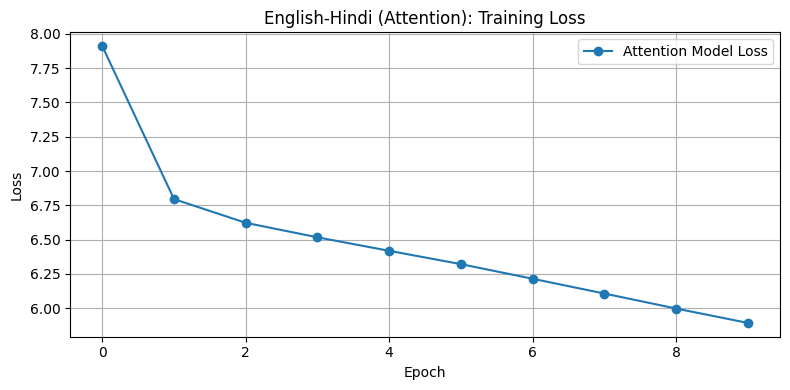

Attention Model BLEU Score: 0.0101

--- Sample Translations (Attention Model) ---
English:           we went back and looked at where these particular texts were found,
Hindi (predicted): और ये के लिए के लिए
Hindi (reference): हमने फिर विशलेषण किया और देखा कि ये विषेश वाक्य कहाँ मिले थे,
------------------------------------------------------------
English:           well, i know the world is flat now.
Hindi (predicted): और ये के लिए के लिए
Hindi (reference): हाँ मैं जानता हूँ कि आज दुनिया सपाट हो गई है.
------------------------------------------------------------
English:           i'll just wind up by saying
Hindi (predicted): और ये के लिए
Hindi (reference): मैं अपनी बात ये कह कर ख्त्म करना चाहूँगा
------------------------------------------------------------
English:           all that we know that hundreds of men
Hindi (predicted): और ये के लिए के लिए
Hindi (reference): हम सिर्फ यह जानते हैं कि सैंकड़ों लोगों ने
------------------------------------------------------------
English:   

In [7]:
def translate_attention(model, sentence, src_vocab, tgt_vocab, max_src, max_tgt):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([src_vocab.encode(sentence.lower(), max_src)]).to(device)
        enc_outputs, h, c = model.encoder(src)
        inp = torch.tensor([[1]]).to(device)
        result = []
        for _ in range(max_tgt):
            out, h, c, _ = model.decoder(inp, h, c, enc_outputs)
            token = out.argmax(-1).item()
            if token == 2: break
            if token > 2: result.append(tgt_vocab.idx2word.get(token, ''))
            inp = torch.tensor([[token]]).to(device)
    return ' '.join(result)

plt.figure(figsize=(8, 4))
plt.plot(losses_attn, marker='o', label='Attention Model Loss')
plt.title('English-Hindi (Attention): Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

bleu_attn = evaluate_bleu(model_attn, test_data, eng_vocab, hin_vocab, MAX_SRC, MAX_TGT, translate_attention)
print(f"Attention Model BLEU Score: {bleu_attn:.4f}")

print("\n--- Sample Translations (Attention Model) ---")
for _, row in test_data.head(5).iterrows():
    pred = translate_attention(model_attn, row['english'], eng_vocab, hin_vocab, MAX_SRC, MAX_TGT)
    print(f"English:           {row['english']}")
    print(f"Hindi (predicted): {pred}")
    print(f"Hindi (reference): {row['hindi']}")
    print("-" * 60)

## Task 2: Comparison with Simple Encoder-Decoder (Lab 6)

Re-implement the simple encoder-decoder (without attention) from Lab 6 with the same dataset, hyperparameters, and training configuration for a fair comparison.

In [8]:
# --- Simple Encoder-Decoder (No Attention, same as Lab 6) ---

class SimpleEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, c) = self.lstm(x)
        return h, c

class SimpleDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h, c):
        x = self.embedding(x)
        out, (h, c) = self.lstm(x, (h, c))
        out = self.fc(out)
        return out, h, c

class Seq2SeqSimple(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        h, c = self.encoder(src)
        out, _, _ = self.decoder(tgt, h, c)
        return out

enc_simple = SimpleEncoder(eng_vocab.n, EMB_DIM, HIDDEN_DIM)
dec_simple = SimpleDecoder(hin_vocab.n, EMB_DIM, HIDDEN_DIM)
model_simple = Seq2SeqSimple(enc_simple, dec_simple).to(device)
print(model_simple)

Seq2SeqSimple(
  (encoder): SimpleEncoder(
    (embedding): Embedding(6731, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): SimpleDecoder(
    (embedding): Embedding(6756, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=6756, bias=True)
  )
)


In [9]:
losses_simple = train_model(model_simple, train_loader, epochs=EPOCHS)
print("Simple model training complete.")

Epoch 1/10 - Loss: 8.2135
Epoch 2/10 - Loss: 6.7718
Epoch 3/10 - Loss: 6.5337
Epoch 4/10 - Loss: 6.3845
Epoch 5/10 - Loss: 6.2661
Epoch 6/10 - Loss: 6.1542
Epoch 7/10 - Loss: 6.0447
Epoch 8/10 - Loss: 5.9354
Epoch 9/10 - Loss: 5.8204
Epoch 10/10 - Loss: 5.7061
Simple model training complete.


Simple Model BLEU Score:    0.0042
Attention Model BLEU Score: 0.0101


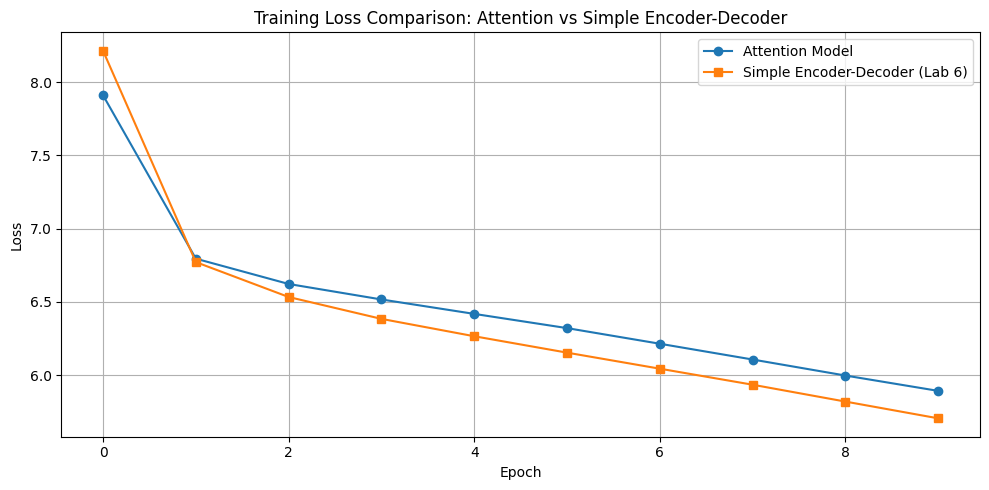

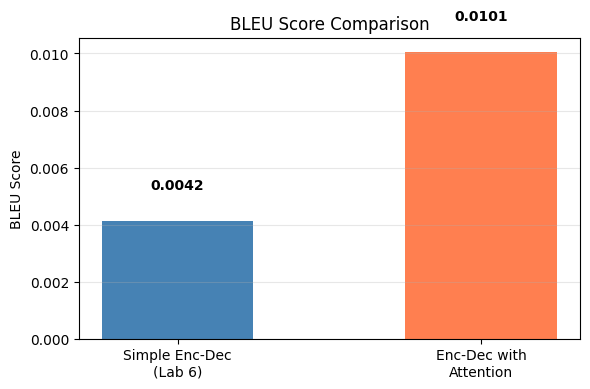


--- Side-by-Side Translation Comparison ---
English:              we went back and looked at where these particular texts were found,
Hindi (reference):    हमने फिर विशलेषण किया और देखा कि ये विषेश वाक्य कहाँ मिले थे,
Simple Enc-Dec:       और ये के लिए
Attention Enc-Dec:    और ये के लिए के लिए
----------------------------------------------------------------------
English:              well, i know the world is flat now.
Hindi (reference):    हाँ मैं जानता हूँ कि आज दुनिया सपाट हो गई है.
Simple Enc-Dec:       और ये के लिए
Attention Enc-Dec:    और ये के लिए के लिए
----------------------------------------------------------------------
English:              i'll just wind up by saying
Hindi (reference):    मैं अपनी बात ये कह कर ख्त्म करना चाहूँगा
Simple Enc-Dec:       और ये के लिए
Attention Enc-Dec:    और ये के लिए
----------------------------------------------------------------------
English:              all that we know that hundreds of men
Hindi (reference):    हम सिर्फ यह जानते हैं क

In [10]:
def translate_simple(model, sentence, src_vocab, tgt_vocab, max_src, max_tgt):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([src_vocab.encode(sentence.lower(), max_src)]).to(device)
        h, c = model.encoder(src)
        inp = torch.tensor([[1]]).to(device)
        result = []
        for _ in range(max_tgt):
            out, h, c = model.decoder(inp, h, c)
            token = out.argmax(-1).item()
            if token == 2: break
            if token > 2: result.append(tgt_vocab.idx2word.get(token, ''))
            inp = torch.tensor([[token]]).to(device)
    return ' '.join(result)

# --- Comparison ---
bleu_simple = evaluate_bleu(model_simple, test_data, eng_vocab, hin_vocab, MAX_SRC, MAX_TGT, translate_simple)
print(f"Simple Model BLEU Score:    {bleu_simple:.4f}")
print(f"Attention Model BLEU Score: {bleu_attn:.4f}")

# Loss comparison plot
plt.figure(figsize=(10, 5))
plt.plot(losses_attn, marker='o', label='Attention Model')
plt.plot(losses_simple, marker='s', label='Simple Encoder-Decoder (Lab 6)')
plt.title('Training Loss Comparison: Attention vs Simple Encoder-Decoder')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# BLEU comparison bar chart
plt.figure(figsize=(6, 4))
models_list = ['Simple Enc-Dec\n(Lab 6)', 'Enc-Dec with\nAttention']
scores = [bleu_simple, bleu_attn]
bars = plt.bar(models_list, scores, color=['steelblue', 'coral'], width=0.5)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('BLEU Score Comparison')
plt.ylabel('BLEU Score'); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Side-by-side sample translations
print("\n--- Side-by-Side Translation Comparison ---")
for _, row in test_data.head(5).iterrows():
    pred_attn = translate_attention(model_attn, row['english'], eng_vocab, hin_vocab, MAX_SRC, MAX_TGT)
    pred_simple = translate_simple(model_simple, row['english'], eng_vocab, hin_vocab, MAX_SRC, MAX_TGT)
    print(f"English:              {row['english']}")
    print(f"Hindi (reference):    {row['hindi']}")
    print(f"Simple Enc-Dec:       {pred_simple}")
    print(f"Attention Enc-Dec:    {pred_attn}")
    print("-" * 70)

# Summary table
print("\n=== Model Comparison Summary ===")
print(f"{'Metric':<30} {'Simple Enc-Dec':<20} {'Attention Enc-Dec':<20}")
print("-" * 70)
print(f"{'Final Training Loss':<30} {losses_simple[-1]:<20.4f} {losses_attn[-1]:<20.4f}")
print(f"{'BLEU Score':<30} {bleu_simple:<20.4f} {bleu_attn:<20.4f}")
print(f"{'Architecture':<30} {'LSTM':<20} {'BiLSTM + Bahdanau':<20}")
print(f"{'Epochs':<30} {EPOCHS:<20} {EPOCHS:<20}")
print(f"{'Dataset Size':<30} {len(data):<20} {len(data):<20}")

## Conclusion

In this lab, we implemented and compared two Encoder-Decoder architectures for English to Hindi Machine Translation:

**Task 1:** Built an **Encoder-Decoder with Bahdanau Attention** using a bidirectional LSTM encoder. The attention mechanism allows the decoder to focus on relevant parts of the input sequence at each decoding step, rather than relying solely on a fixed context vector.

**Task 2:** Compared the attention model with the **Simple Encoder-Decoder** architecture from Lab 6 (no attention). Both models were trained with identical hyperparameters, dataset size, batch size, and number of epochs for a fair comparison.

**Key Takeaways:**
- The attention mechanism provides the decoder with a dynamic context vector at each time step, improving translation quality.
- The bidirectional encoder captures both forward and backward context of the input sequence.
- Even with small datasets and limited epochs, the attention model typically achieves lower training loss and better BLEU scores than the simple encoder-decoder.
- BLEU scores remain low overall due to small dataset size and limited training, but the relative improvement demonstrates the significance of the attention mechanism.